In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import measure as ms 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

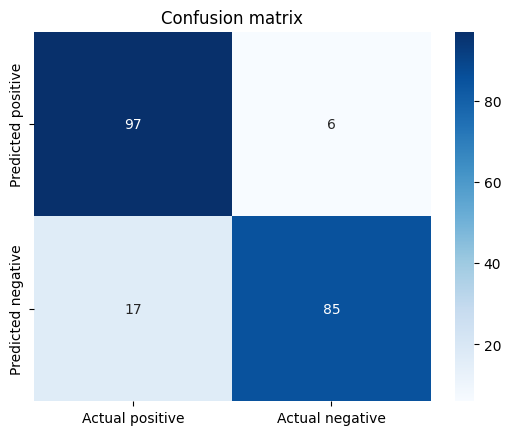

Accuracy: 0.89
Precision: 0.85
Recall: 0.94
Specificity: 0.83
F1 score: 0.89


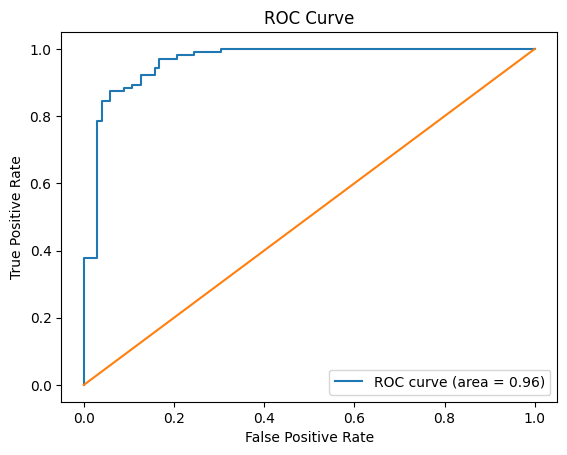

In [12]:
data = pd.read_csv('dataset/heart.csv')

y = data['target']

X = data.drop('target', axis=1)   # change 'target' if your column name differs
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVC(kernel='rbf', probability=True)  # probability=True needed for ROC
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_test = y_test.values
y_pred = y_pred

tp, fp, fn, tn = ms.getConfusionMatrixEntries(y_pred, y_test)
ms.confusionMatrix(tp, fp, fn, tn)
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1])  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()